![digitizing_team](digitizing_team.png)


DigiNsure Inc. is an innovative insurance company focused on enhancing the efficiency of processing claims and customer service interactions. Their newest initiative is digitizing all historical insurance claim documents, which includes improving the labeling of some IDs scanned from paper documents and identifying them as primary or secondary IDs.

To help them in their effort, you'll be using multi-modal learning to train an Optical Character Recognition (OCR) model. To improve the classification, the model will use **images** of the scanned documents as input and their **insurance type** (home, life, auto, health, or other). Integrating different data modalities (such as image and text) enables the model to perform better in complex scenarios, helping to capture more nuanced information. The **labels** that the model will be trained to identify are of two types: a primary and a secondary ID, for each image-insurance type pair.

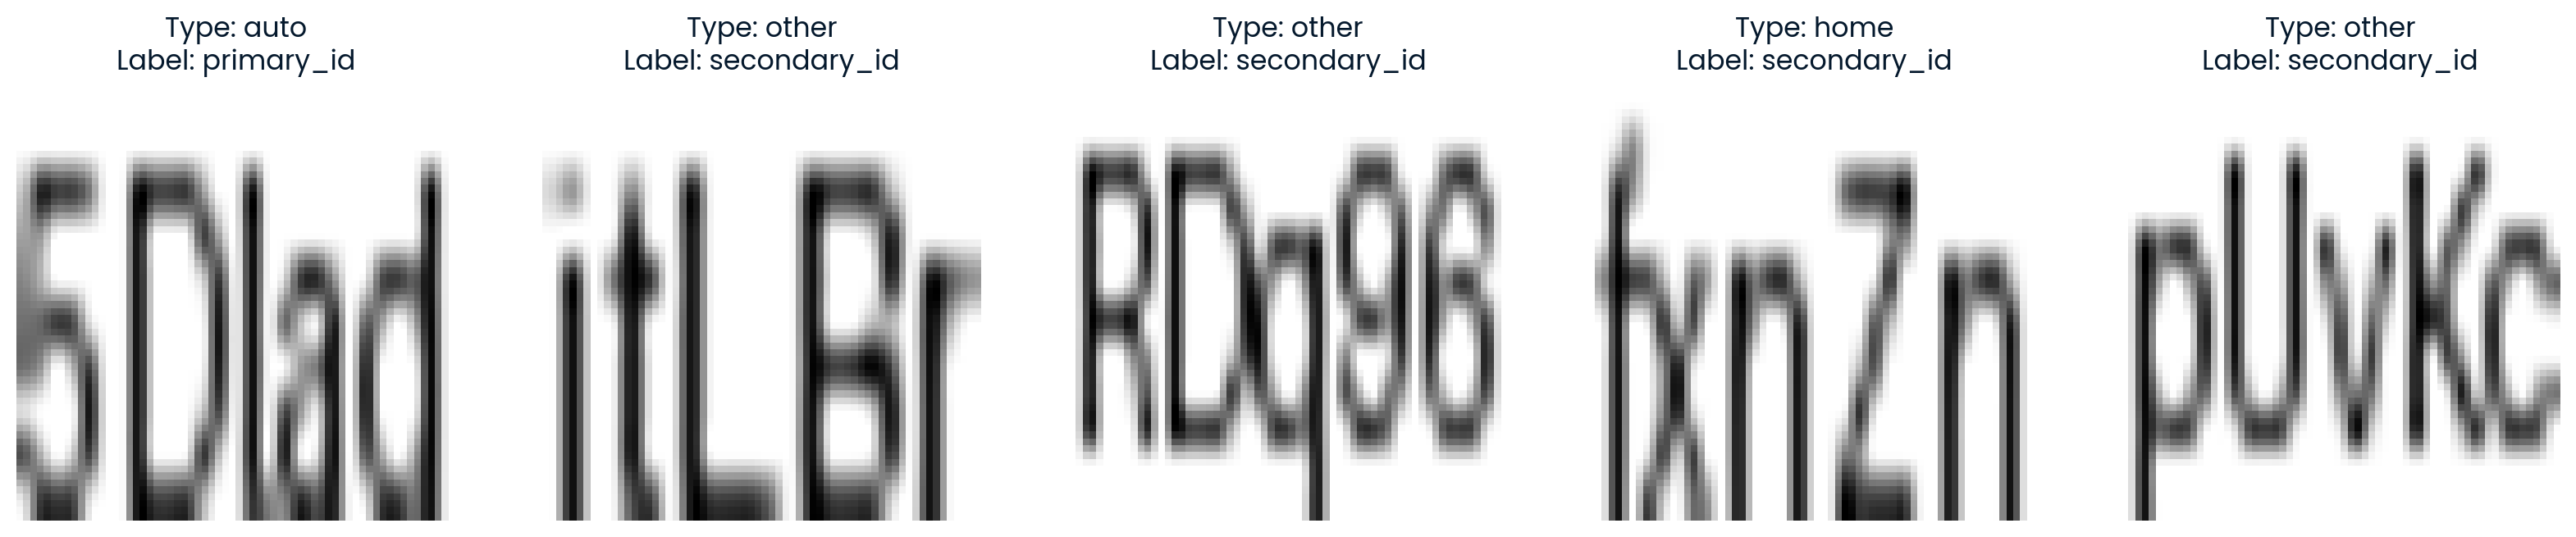

Training samples: 80
Validation samples: 20

Model initialized on device: cpu
Total parameters: 2108066

Starting training...
------------------------------------------------------------
Epoch [1/10]
  Train Loss: 0.8412 | Train Acc: 45.00%
  Val Loss: 0.6668 | Val Acc: 65.00%
------------------------------------------------------------
Epoch [2/10]
  Train Loss: 0.6859 | Train Acc: 55.00%
  Val Loss: 0.7752 | Val Acc: 35.00%
------------------------------------------------------------
Epoch [3/10]
  Train Loss: 0.6997 | Train Acc: 48.75%
  Val Loss: 0.6826 | Val Acc: 65.00%
------------------------------------------------------------
Epoch [4/10]
  Train Loss: 0.6803 | Train Acc: 50.00%
  Val Loss: 0.7030 | Val Acc: 35.00%
------------------------------------------------------------
Epoch [5/10]
  Train Loss: 0.6767 | Train Acc: 55.00%
  Val Loss: 0.7439 | Val Acc: 35.00%
------------------------------------------------------------
Epoch [6/10]
  Train Loss: 0.6732 | Train Acc: 51.25%

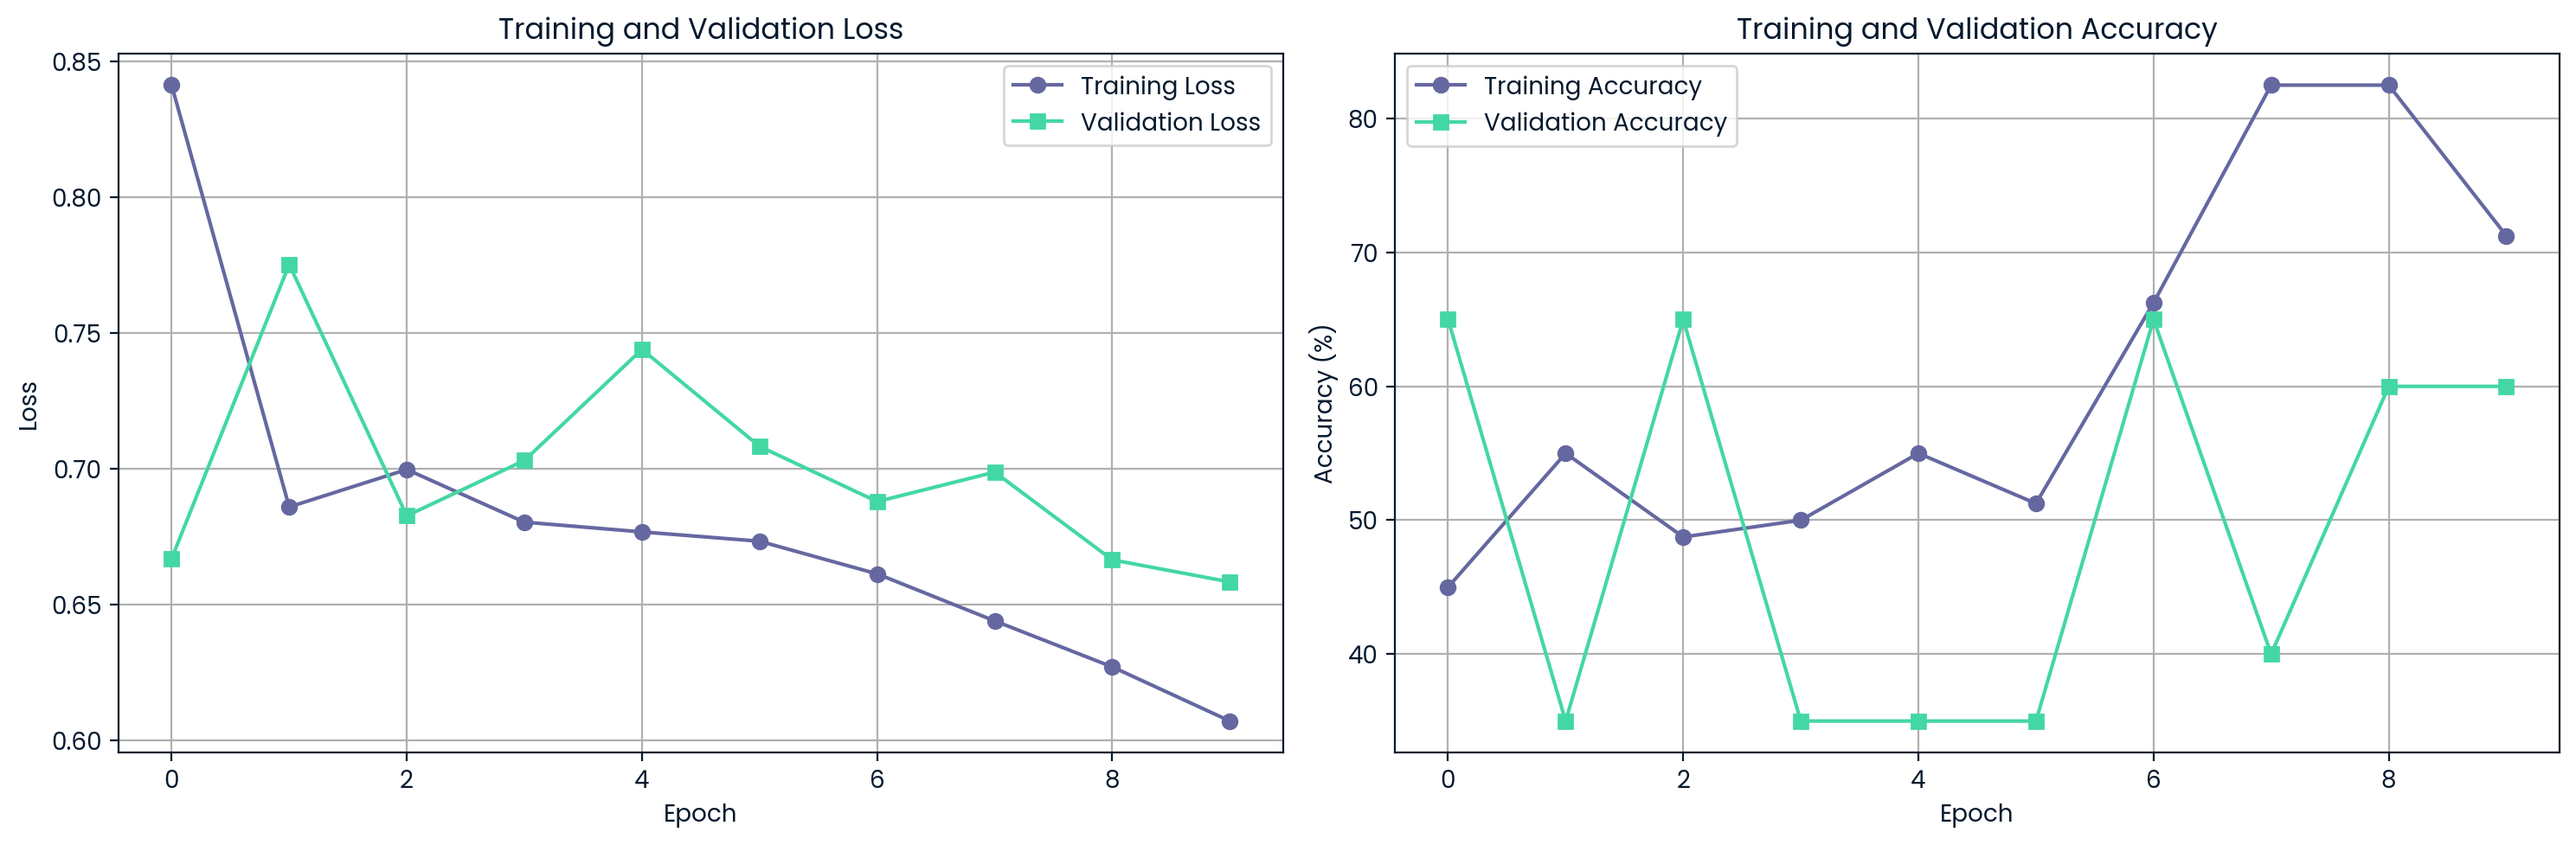


Final Results:
Best Validation Accuracy: 65.00%
Final Validation Accuracy: 60.00%


In [3]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from project_utils import ProjectDataset
import pickle 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Load the data
dataset = pickle.load(open('ocr_insurance_dataset.pkl', 'rb'))

# Define a function to visualize codes with their corresponding types and labels 
def show_dataset_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, min(num_images, len(dataset)), figsize=(20, 4))
    for ax, idx in zip(axes, np.random.choice(len(dataset), min(num_images, len(dataset)), False)):
        img, lbl = dataset[idx]
        ax.imshow((img[0].numpy() * 255).astype(np.uint8).reshape(64,64), cmap='gray'), ax.axis('off')
        ax.set_title(f"Type: {list(dataset.type_mapping.keys())[img[1].tolist().index(1)]}\nLabel: {list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(lbl)]}")
    plt.show()

# Inspect 5 codes images from the dataset
show_dataset_images(dataset)

# Split the dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Define the OCRModel class
class OCRModel(nn.Module):
    def __init__(self, num_insurance_types=5, num_classes=2):
        super(OCRModel, self).__init__()
        
        # Image layers as a sequential module for 64x64 images
        self.image_layer = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(16 * 32 * 32, 128),
            nn.ReLU()
        )
        
        # Insurance type processing layers
        self.type_layer = nn.Sequential(
            nn.Linear(num_insurance_types, 32),
            nn.ReLU()
        )
        
        # Fusion layers to combine both modalities
        self.fusion_layer = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        # x is a tuple of (image, insurance_type)
        image, insurance_type = x
        
        # Process image through image_layer
        image_features = self.image_layer(image)
        
        # Process insurance type
        type_features = self.type_layer(insurance_type)
        
        # Concatenate features from both modalities
        combined = torch.cat((image_features, type_features), dim=1)
        
        # Pass through fusion layers
        output = self.fusion_layer(combined)
        
        return output

# Initialize the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = OCRModel(num_insurance_types=5, num_classes=2).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"\nModel initialized on device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        # Unpack inputs (image and insurance type)
        images = inputs[0].to(device)
        types = inputs[1].to(device)
        labels = labels.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model((images, types))
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            images = inputs[0].to(device)
            types = inputs[1].to(device)
            labels = labels.to(device)
            
            outputs = model((images, types))
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

# Training loop for 10 epochs
num_epochs = 10
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print("\nStarting training...")
print("-" * 60)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print("-" * 60)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Training Loss', marker='o')
ax1.plot(val_losses, label='Validation Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Training Accuracy', marker='o')
ax2.plot(val_accuracies, label='Validation Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {max(val_accuracies):.2f}%")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")

In [4]:
# Start coding here 